# Bài tập thực hành tuần 8
> Họ và tên: Nguyễn Vạn Phúc Huy <br>
> MSSV: 23110163 <br>
> Lớp: 23TTH (Chiều thứ 6, ca 1)

In [20]:
import random
import numpy as np
import pandas as pd
import seaborn as sns
import scipy.cluster.hierarchy as sch
import matplotlib.pyplot as plt
from sklearn.cluster import AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans



### Thực thi đoạn code ở mục 1

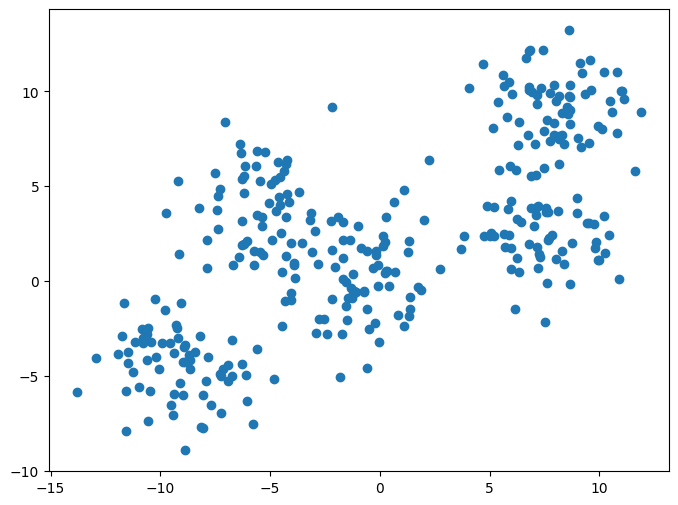

In [21]:
random.seed(234)
np.random.seed(234)

x, _ = make_blobs(n_samples=330, centers=5, cluster_std=1.84)
plt.figure(figsize=(8, 6))
plt.scatter(x[:, 0], x[:, 1])
plt.show()

In [22]:
gm = GaussianMixture(n_components=5).fit(x)
centers = gm.means_
print(centers)

[[-5.55836831  3.87299888]
 [ 7.28418475  2.56387124]
 [-0.90246061  0.16230294]
 [-9.18288987 -4.47852917]
 [ 8.11454324  9.24741885]]


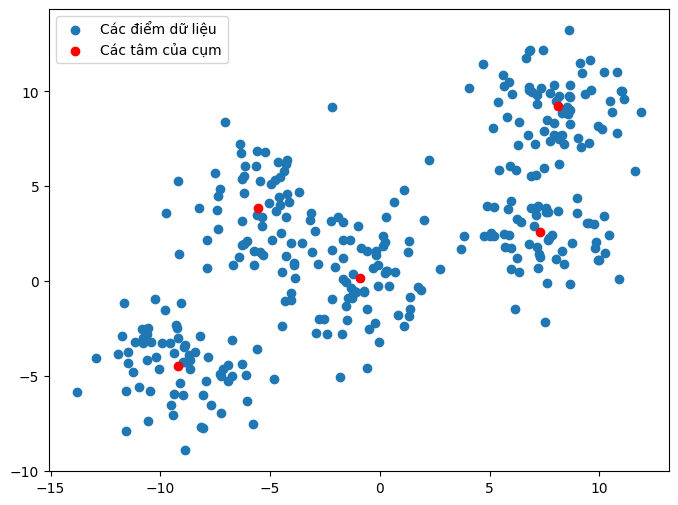

In [23]:
plt.figure(figsize=(8, 6))
plt.scatter(x[:, 0], x[:, 1], label='Các điểm dữ liệu')
plt.scatter(centers[:, 0], centers[:, 1], color='red', label='Các tâm của cụm')
plt.legend()
plt.show()

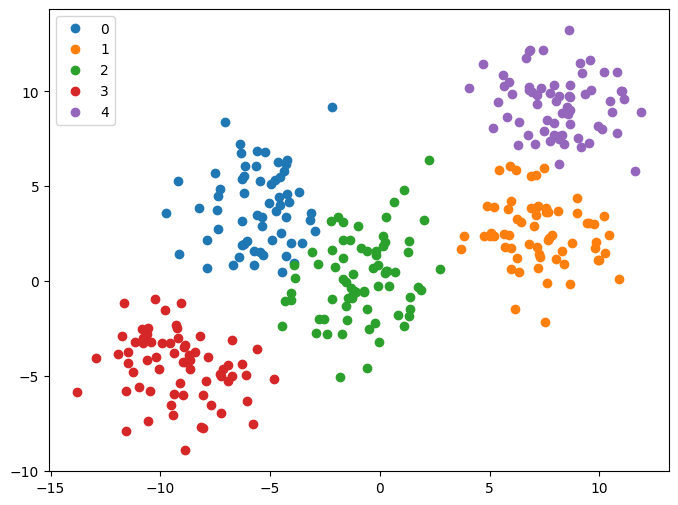

In [24]:
pred = gm.predict(x)

df = pd.DataFrame({'x': x[:, 0], 'y': x[:, 1], 'cluster': pred})
groups = df.groupby('cluster')

fig, ax = plt.subplots(figsize=(8, 6))
for name, group in groups:
    ax.plot(group.x, group.y, marker='o', linestyle='', label=name)

ax.legend()
plt.show()

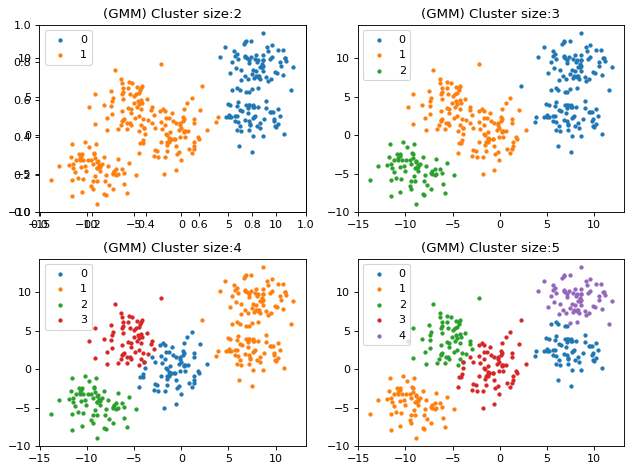

In [25]:
f = plt.figure(figsize=(8, 6), dpi=80)
f.add_subplot(2,2,1)

for i in range(2, 6):
    gm = GaussianMixture(n_components=i).fit(x)
    pred = gm.predict(x)
    df = pd.DataFrame({'x': x[:, 0], 'y': x[:, 1], 'label': pred})
    groups = df.groupby('label')
    f.add_subplot(2,2,i-1)
    for name, group in groups:
        plt.scatter(group.x, group.y, label=name, s = 8)
        plt.title(f'(GMM) Cluster size:' + str(i))
        plt.legend()
    
    
plt.tight_layout()
plt.show()

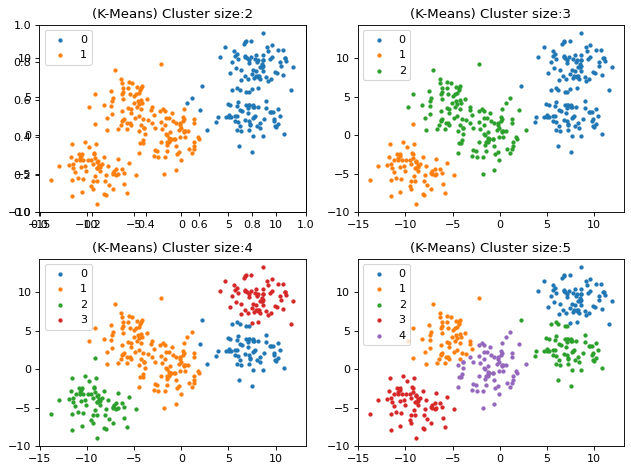

In [26]:
f = plt.figure(figsize=(8, 6), dpi=80)
f.add_subplot(2,2,1)

for i in range(2, 6):
    km = KMeans(n_clusters=i).fit(x)
    pred = km.predict(x)
    df = pd.DataFrame({'x': x[:, 0], 'y': x[:, 1], 'label': pred})
    groups = df.groupby('label')
    f.add_subplot(2,2,i-1)
    for name, group in groups:
        plt.scatter(group.x, group.y, label=name, s = 8)
        plt.title(f'(K-Means) Cluster size:' + str(i))
        plt.legend()
        
plt.tight_layout()
plt.show()


### Cài đặt thuật toán Mahalanobis k-means

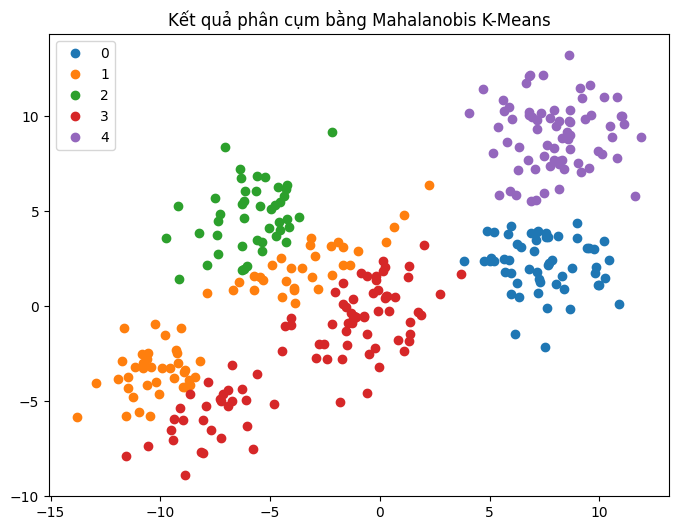

In [29]:
class MahalanobisKMeans:
    def __init__(self, n_clusters=3, max_iter=100, tol=1e-4, reg_covar=1e-6):
        self.n_clusters = n_clusters
        self.max_iter = max_iter
        self.tol = tol
        self.reg_covar = reg_covar

    def fit(self, X):
        n_samples, n_features = X.shape
        
        # 1. Khởi tạo ngẫu nhiên tâm cụm (centroids)
        random_idx = np.random.permutation(n_samples)[:self.n_clusters]
        self.centroids = X[random_idx]
        
        # Khởi tạo ma trận nghịch đảo hiệp phương sai (ma trận đơn vị) và log_det = 0
        self.inv_covariances = [np.eye(n_features) for _ in range(self.n_clusters)]
        self.log_dets = np.zeros(self.n_clusters)
        self.labels = np.zeros(n_samples)
        
        for iteration in range(self.max_iter):
            old_centroids = self.centroids.copy()
            
            # 2. Bước Gán (Assignment): Tính khoảng cách Mahalanobis + log_det penalty
            distances = np.zeros((n_samples, self.n_clusters))
            for k in range(self.n_clusters):
                diff = X - self.centroids[k]
                # Mahalanobis distance + ln(|Sigma|)
                mahalanobis_dist = np.sum(np.dot(diff, self.inv_covariances[k]) * diff, axis=1)
                distances[:, k] = mahalanobis_dist + self.log_dets[k]
                
            self.labels = np.argmin(distances, axis=1)
            
            # 3. Bước Cập nhật (Update)
            for k in range(self.n_clusters):
                cluster_data = X[self.labels == k]
                
                if len(cluster_data) > 1:
                    self.centroids[k] = np.mean(cluster_data, axis=0)
                    cov_matrix = np.cov(cluster_data, rowvar=False)
                    cov_matrix += np.eye(n_features) * self.reg_covar
                    
                    self.inv_covariances[k] = np.linalg.inv(cov_matrix)
                    
                    # Tính logarit định thức một cách an toàn (tránh underflow/overflow)
                    sign, log_det = np.linalg.slogdet(cov_matrix)
                    self.log_dets[k] = log_det
                
            # 4. Kiểm tra hội tụ
            shift = np.linalg.norm(self.centroids - old_centroids)
            if shift < self.tol:
                break
                
        return self

    def predict(self, X):
        n_samples = X.shape[0]
        distances = np.zeros((n_samples, self.n_clusters))
        for k in range(self.n_clusters):
            diff = X - self.centroids[k]
            mahalanobis_dist = np.sum(np.dot(diff, self.inv_covariances[k]) * diff, axis=1)
            # Khi predict dữ liệu mới cũng phải cộng log_det của cụm đó
            distances[:, k] = mahalanobis_dist + self.log_dets[k]
            
        return np.argmin(distances, axis=1)
    
# Tạo dữ liệu mẫu
random.seed(234)
np.random.seed(234)
x, _ = make_blobs(n_samples=330, centers=5, cluster_std=1.84)
# Áp dụng Mahalanobis K-Means
mk = MahalanobisKMeans(n_clusters=5, max_iter=100, tol=1e-6, reg_covar=1e-6)
mk.fit(x)
pred_mk = mk.predict(x)
# Trực quan hóa kết quả
df_mk = pd.DataFrame({'x': x[:, 0], 'y': x[:, 1], 'cluster': pred_mk})
groups_mk = df_mk.groupby('cluster')
fig, ax = plt.subplots(figsize=(8, 6))
for name, group in groups_mk:
    ax.plot(group.x, group.y, marker='o', linestyle='', label=name)
ax.legend()
plt.title('Kết quả phân cụm bằng Mahalanobis K-Means')
plt.show()
